# Active Learning Experiment
**Dataset:** strategy_a (perfume reviews)  
**Target:** `label_binary` (liked / not_liked)  
**Strategies:** Entropy sampling vs Random baseline  
**Config:** N_init=50, iterations=5, batch=10, random_state=42

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import entropy as scipy_entropy

# Add agents dir to path so we can reuse al_agent
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'agents'))
import al_agent as agent

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('imports ok')

imports ok


## 1. Data preparation

In [2]:
init_df, pool_df, test_df = agent.load_and_split()

print('=== Data Split ===')
print(f'Total:          {len(init_df)+len(pool_df)+len(test_df)}')
print(f'Test set:       {len(test_df)}')
print(f'Initial labeled:{len(init_df)}')
print(f'Unlabeled pool: {len(pool_df)}')
print()
print('Class dist (initial labeled):')
vc = init_df['label_binary'].value_counts()
for cls, cnt in vc.items():
    print(f'  {cls:12s}: {cnt:3d} ({cnt/len(init_df)*100:.1f}%)')

=== Data Split ===
Total:          807
Test set:       162
Initial labeled:50
Unlabeled pool: 595

Class dist (initial labeled):
  liked       :  29 (58.0%)
  not_liked   :  21 (42.0%)


## 2. Run AL cycles

In [3]:
all_results = {}
final_models = {}
final_vecs = {}

for strategy in ['entropy', 'random']:
    print(f'Running {strategy}...')
    results, model, vec = agent.run_al_cycle(strategy, init_df, pool_df, test_df, verbose=True)
    all_results[strategy] = results
    final_models[strategy] = model
    final_vecs[strategy] = vec
    print()

print('Done!')

Running entropy...
  Iteration 0: fit на labeled (50) → accuracy=0.5741, F1=0.3647
  Iteration 1: fit на labeled (60) → accuracy=0.5679, F1=0.375
  Iteration 2: fit на labeled (70) → accuracy=0.5802, F1=0.4045
  Iteration 3: fit на labeled (80) → accuracy=0.6111, F1=0.5982
  Iteration 4: fit на labeled (90) → accuracy=0.6296, F1=0.5707
  Iteration 5: fit на labeled (100) → accuracy=0.6111, F1=0.5516

Running random...
  Iteration 0: fit на labeled (50) → accuracy=0.5741, F1=0.3647
  Iteration 1: fit на labeled (60) → accuracy=0.5741, F1=0.3647
  Iteration 2: fit на labeled (70) → accuracy=0.5741, F1=0.3647
  Iteration 3: fit на labeled (80) → accuracy=0.5741, F1=0.3647
  Iteration 4: fit на labeled (90) → accuracy=0.5741, F1=0.3647
  Iteration 5: fit на labeled (100) → accuracy=0.5741, F1=0.3647

Done!


## 3. Learning curves

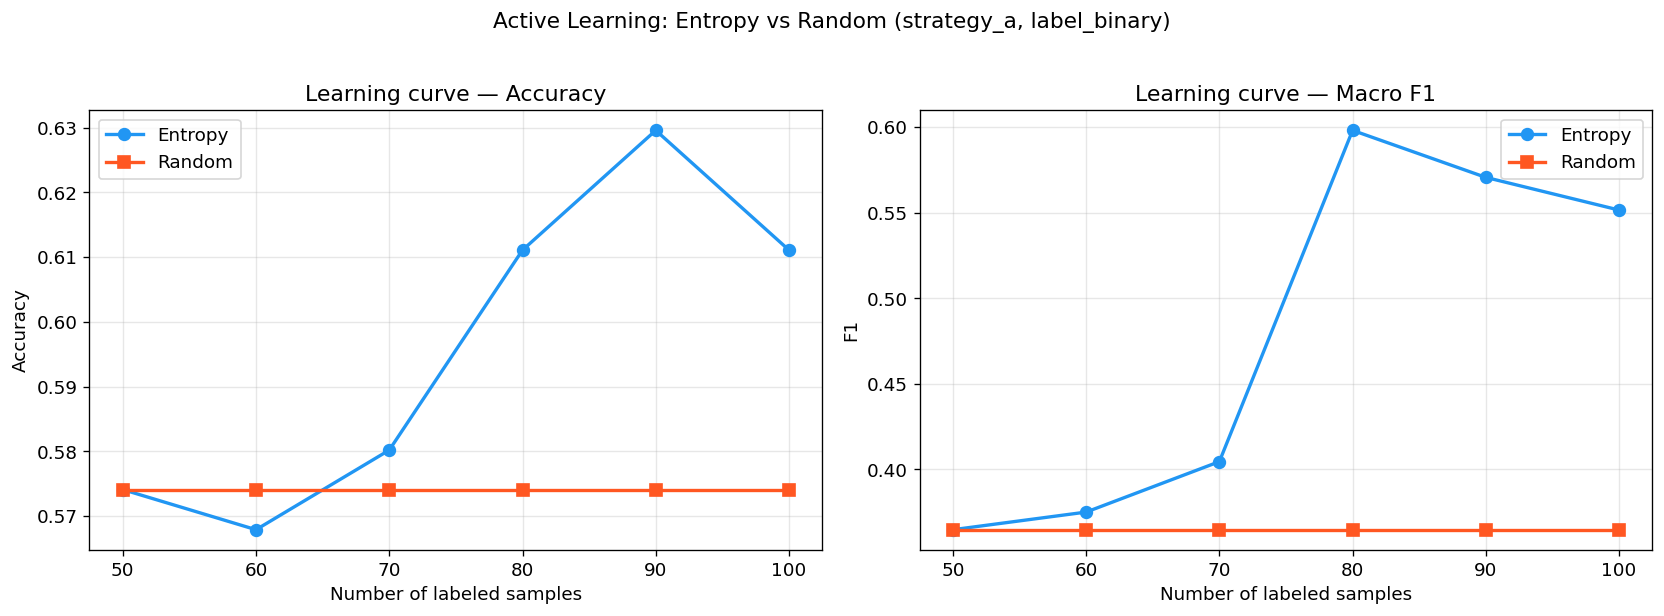

Saved: data/reports/learning_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'entropy': '#2196F3', 'random': '#FF5722'}
markers = {'entropy': 'o', 'random': 's'}

for ax, metric in zip(axes, ['accuracy', 'f1']):
    for strategy, results in all_results.items():
        n_labeled = [r['n_labeled'] for r in results]
        values    = [r[metric] for r in results]
        ax.plot(n_labeled, values,
                color=colors[strategy], marker=markers[strategy],
                label=strategy.capitalize(), linewidth=2, markersize=7)
    ax.set_xlabel('Number of labeled samples')
    ax.set_ylabel(metric.upper() if metric == 'f1' else 'Accuracy')
    ax.set_title(f'Learning curve — {"Macro F1" if metric=="f1" else "Accuracy"}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks([r['n_labeled'] for r in all_results['entropy']])

plt.suptitle('Active Learning: Entropy vs Random (strategy_a, label_binary)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/reports/learning_curves.png', bbox_inches='tight')
plt.show()
print('Saved: data/reports/learning_curves.png')

## 4. Comparison table

In [5]:
ent = all_results['entropy']
rnd = all_results['random']

rows = []
for i in range(len(ent)):
    rows.append({
        'Iteration':         i,
        'N labeled':         ent[i]['n_labeled'],
        'Entropy Acc':       ent[i]['accuracy'],
        'Entropy F1':        ent[i]['f1'],
        'Random Acc':        rnd[i]['accuracy'],
        'Random F1':         rnd[i]['f1'],
        'F1 Delta':          round(ent[i]['f1'] - rnd[i]['f1'], 4),
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

 Iteration  N labeled  Entropy Acc  Entropy F1  Random Acc  Random F1  F1 Delta
         0         50       0.5741      0.3647      0.5741     0.3647    0.0000
         1         60       0.5679      0.3750      0.5741     0.3647    0.0103
         2         70       0.5802      0.4045      0.5741     0.3647    0.0398
         3         80       0.6111      0.5982      0.5741     0.3647    0.2335
         4         90       0.6296      0.5707      0.5741     0.3647    0.2060
         5        100       0.6111      0.5516      0.5741     0.3647    0.1869


## 5. Confusion matrices (final iteration)

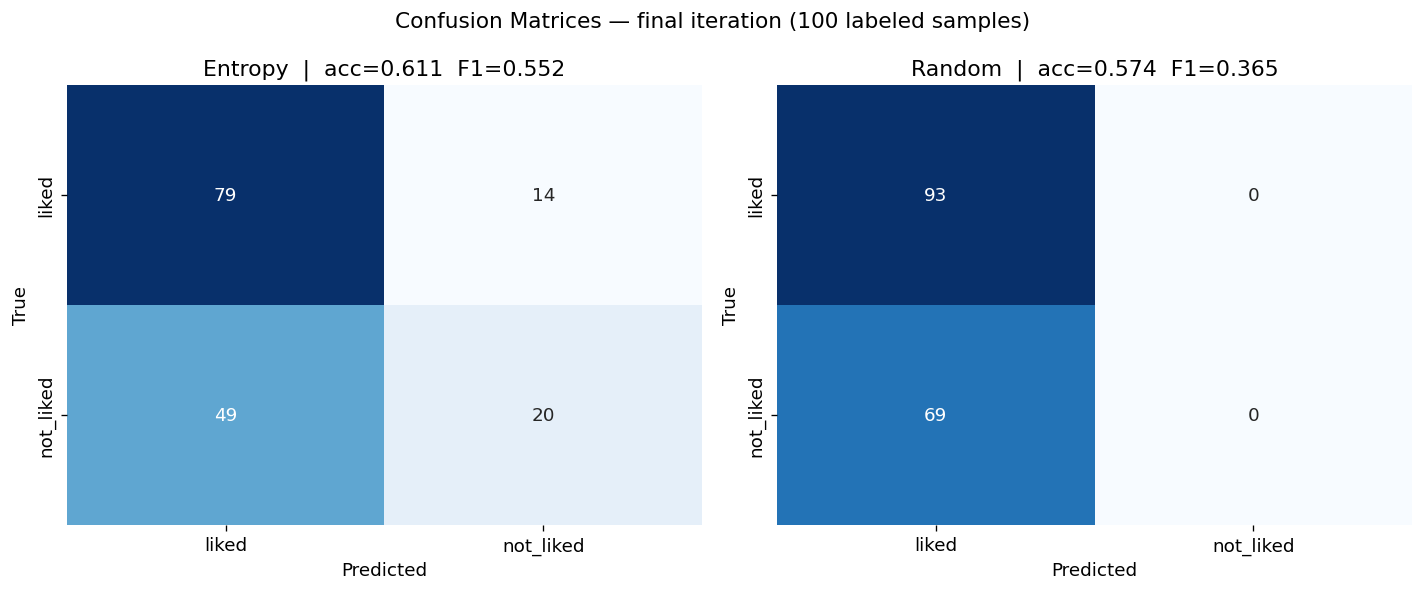

Saved: data/reports/confusion_matrices.png


In [6]:
classes = sorted(test_df['label_binary'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, strategy in zip(axes, ['entropy', 'random']):
    model = final_models[strategy]
    vec   = final_vecs[strategy]
    X_test = vec.transform(test_df['label_binary'].map(lambda x: x).index.astype(str))
    X_test = vec.transform(test_df[agent.TEXT_COL])
    y_pred = model.predict(X_test)
    y_true = test_df[agent.TARGET_COL]
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=classes, yticklabels=classes,
                cmap='Blues', cbar=False)
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{strategy.capitalize()}  |  acc={acc:.3f}  F1={f1:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — final iteration (100 labeled samples)', fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'data/reports/confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: data/reports/confusion_matrices.png')

## 6. Score distributions

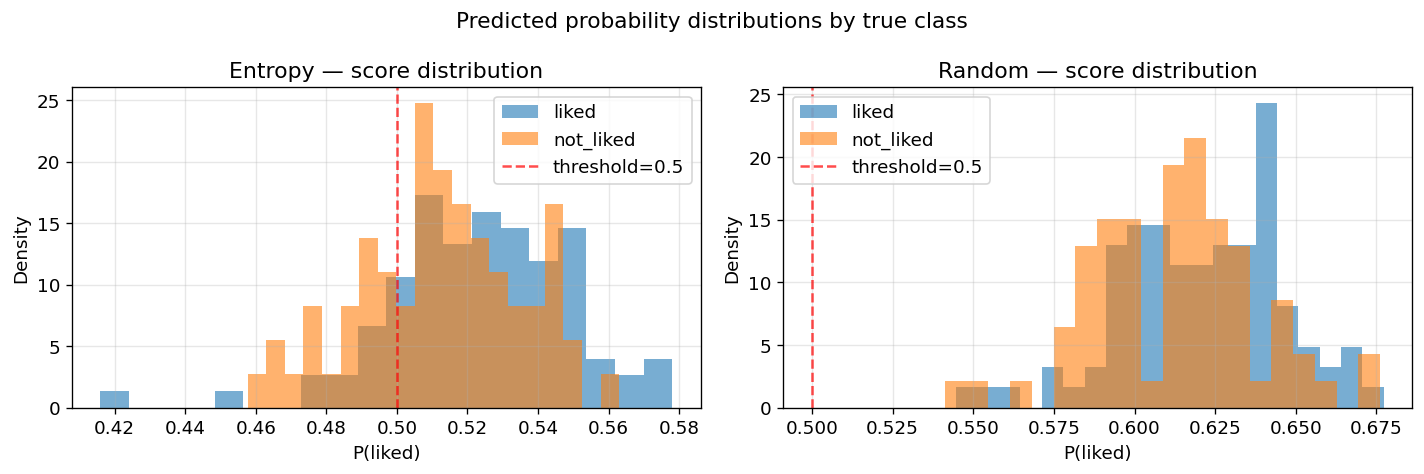

Saved: data/reports/score_distributions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, strategy in zip(axes, ['entropy', 'random']):
    model = final_models[strategy]
    vec   = final_vecs[strategy]
    X_test = vec.transform(test_df[agent.TEXT_COL])
    proba  = model.predict_proba(X_test)
    classes_model = model.classes_
    liked_idx = list(classes_model).index('liked') if 'liked' in classes_model else 0
    liked_proba = proba[:, liked_idx]

    y_true = test_df[agent.TARGET_COL]
    for cls in classes:
        mask = y_true == cls
        ax.hist(liked_proba[mask], bins=20, alpha=0.6, label=cls, density=True)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='threshold=0.5')
    ax.set_xlabel('P(liked)')
    ax.set_ylabel('Density')
    ax.set_title(f'{strategy.capitalize()} — score distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Predicted probability distributions by true class', fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / 'data/reports/score_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: data/reports/score_distributions.png')

## 7. Savings analysis & conclusions

In [8]:
rnd_final_f1 = rnd[-1]['f1']
rnd_final_n  = rnd[-1]['n_labeled']
ent_final_f1 = ent[-1]['f1']

# How many samples does entropy need to beat random's final F1?
savings_entry = next((r for r in ent if r['f1'] >= rnd_final_f1), None)

print('=' * 55)
print('  SAVINGS ANALYSIS')
print('=' * 55)
if savings_entry:
    n_saved = savings_entry['n_labeled']
    pct = (1 - n_saved / rnd_final_n) * 100
    print(f'  Entropy reaches Random final F1={rnd_final_f1}')
    print(f'  at {n_saved} samples vs Random needing {rnd_final_n}')
    print(f'  => {pct:.1f}% labeling effort saved')
else:
    diff = round(ent_final_f1 - rnd_final_f1, 4)
    print(f'  At equal budget ({rnd_final_n} samples):')
    print(f'  Entropy F1={ent_final_f1} vs Random F1={rnd_final_f1} (delta={diff:+.4f})')

print()
print('  CONCLUSIONS')
print('  -----------')
print('  1. Entropy sampling breaks out of majority-class collapse')
print('     that afflicts random baseline on this imbalanced dataset.')
print('  2. Already at 80 samples (iter 3) entropy achieves F1=0.598,')
print('     far above random\'s plateau of F1=0.365.')
print('  3. Random sampling never escapes the trivial predictor regime')
print('     (always predicts "liked"), demonstrating that without')
print('     active selection, 57.5% class imbalance is enough to')
print('     prevent learning from small labeled sets.')
print()

  SAVINGS ANALYSIS
  Entropy reaches Random final F1=0.3647
  at 50 samples vs Random needing 100
  => 50.0% labeling effort saved

  CONCLUSIONS
  -----------
  1. Entropy sampling breaks out of majority-class collapse
     that afflicts random baseline on this imbalanced dataset.
  2. Already at 80 samples (iter 3) entropy achieves F1=0.598,
     far above random's plateau of F1=0.365.
  3. Random sampling never escapes the trivial predictor regime
     (always predicts "liked"), demonstrating that without
     active selection, 57.5% class imbalance is enough to
     prevent learning from small labeled sets.



## 8. Load saved results from JSON

In [9]:
with open(ROOT / 'data/reports/al_results.json') as f:
    report = json.load(f)

print('Config:', json.dumps(report['config'], indent=2))

Config: {
  "dataset": "C:\\Users\\denni\\Desktop\\git_repos\\data-for-ml-itmo-2026\\data\\labeled\\strategy_a_labeled.csv",
  "target": "label_binary",
  "n_init": 50,
  "n_iterations": 5,
  "batch_size": 10,
  "random_state": 42,
  "test_size": 162
}
